In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import nltk

nltk.download('punkt')
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer, HashingVectorizer
from sklearn.pipeline import Pipeline
from wordcloud import WordCloud, STOPWORDS
from transformers import pipeline
from sklearn.svm import LinearSVC
import plotly.express as px

[nltk_data] Downloading package punkt to /home/samsam/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [19]:
df = pd.read_csv('data/hasilPreprocessing.csv')

In [20]:
# Load sentiment classifier
classifier = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier"
)

# bersihkan kolom
df['Comment'] = df['Comment'].fillna("").astype(str)

# Jika ada list (hasil tokenizing), ubah ke string
df['Comment'] = df['Comment'].apply(
    lambda x: " ".join(x) if isinstance(x, list) else x
)

# Fungsi prediksi sentimen (versi aman)
def prediksi_sentimen(teks):
    teks = str(teks).strip()

    # handle kosong / aneh
    if teks == "" or len(teks) < 2:
        return "neutral"

    try:
        hasil = classifier(teks)
        return hasil[0]['label']
    except Exception as e:
        return "error"

# Terapkan ke dataframe
df['sentimen'] = df['Comment'].apply(prediksi_sentimen)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:
df

,Comment,sentimen
0,wajar prabowo depan penting cetak man power ti...,neutral
1,subsidi bbm mau alih full mbg bungg,neutral
2,diskusi buka mata indonesia,neutral
3,senang lihat podcast,positive
4,simed ready receive this blessing from univers...,negative
...,...,...
3538,herewego,negative
3539,baru kali nonton youtube konten keluar ditungguin,neutral
3540,gass purbaya masyarakat selalu dukung jabat pi...,positive
3541,tunggu tunggu,negative


In [22]:
sentimen_counts = df.sentimen.value_counts()
sentimen_counts

sentimen
neutral     1317
negative    1271
positive     955
Name: count, dtype: int64

In [23]:
df.to_csv("hasilindonesian-roberta.csv", index=False)
df

,Comment,sentimen
0,wajar prabowo depan penting cetak man power ti...,neutral
1,subsidi bbm mau alih full mbg bungg,neutral
2,diskusi buka mata indonesia,neutral
3,senang lihat podcast,positive
4,simed ready receive this blessing from univers...,negative
...,...,...
3538,herewego,negative
3539,baru kali nonton youtube konten keluar ditungguin,neutral
3540,gass purbaya masyarakat selalu dukung jabat pi...,positive
3541,tunggu tunggu,negative


# Exploratory Data Analysis (EDA)

## Bar chart

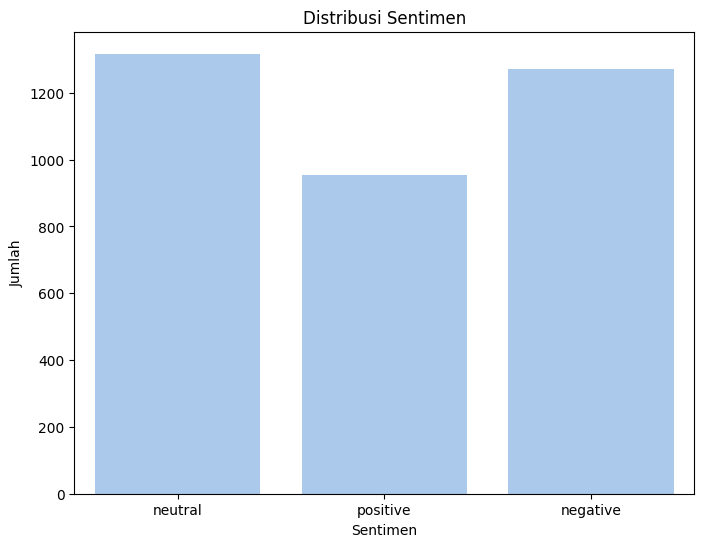

In [24]:
sns.set_palette("pastel")
plt.figure(figsize=(8, 6))
sns.countplot(x='sentimen', data=df)
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

## sentimen terhadap kata

In [25]:
#sentimen kata "purbaya"

In [26]:
import pandas as pd

kata = "purbaya"

SentimenPurbaya = df[df["Comment"].str.contains(kata, case=False, na=False)]

print(SentimenPurbaya[["Comment", "sentimen"]])

                                                Comment  sentimen
35    bener obrol kwalitas hebat obrol paham mari aj...  positive
46       tahun purbaya president wakil president dharma   neutral
47                                  istri purbaya keren   neutral
53    makasih purbaya baya sehat selalu buat purbaya...  positive
61    diskusi luar biasa orang orang pinter aset ban...  positive
...                                                 ...       ...
3523                                when purbaya cooked  negative
3527  philofis balik bijak ekonomi purbaya awal tery...   neutral
3531              terimakasih atas insight purbaya gita   neutral
3535  wah tunggu ikut simak terima kasih gita tim en...  positive
3540  gass purbaya masyarakat selalu dukung jabat pi...  positive

[636 rows x 2 columns]


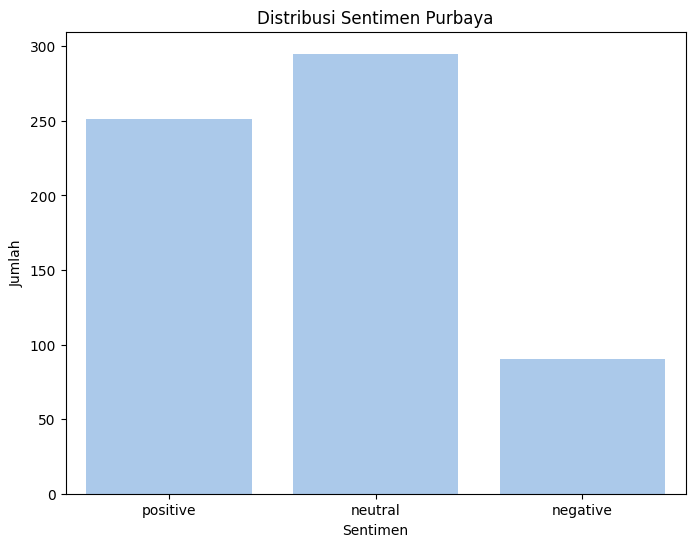

In [27]:
sns.set_palette("pastel")
plt.figure(figsize=(8, 6))
sns.countplot(x='sentimen', data=SentimenPurbaya)
plt.title('Distribusi Sentimen Purbaya')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

In [28]:
# sentimen kata "presiden" dan "prabowo"

In [29]:
kata_list = ["presiden", "prabowo"]

pattern = "|".join(kata_list)

SentimenPrabowo = df[df["Comment"].str.contains(pattern, case=False, na=False)]
print(SentimenPrabowo[["Comment", "sentimen"]])

                                                Comment  sentimen
0     wajar prabowo depan penting cetak man power ti...   neutral
25               bareng perintah prabowo bawa ubah asli   neutral
46       tahun purbaya president wakil president dharma   neutral
49                                  orang jadi presiden   neutral
104   masalah birokrasi bagai mana baik purbaya menk...  positive
...                                                 ...       ...
3335  mantan bantu jkw luhut pantes pinter knp tidak...  negative
3402                                undang prabowo gita   neutral
3426                                  tamu ikut prabowo   neutral
3475  prabowo pikir agresif pengganggudiplihara bgmn...  negative
3500                                  urus presiden dpr   neutral

[87 rows x 2 columns]


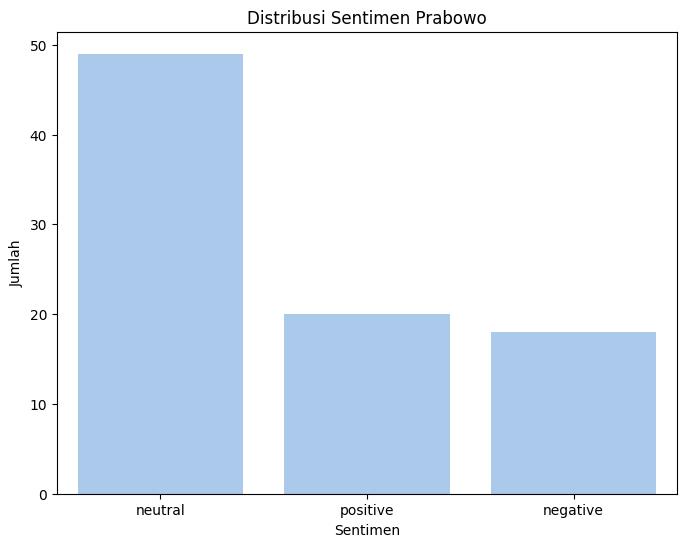

In [30]:
sns.set_palette("pastel")
plt.figure(figsize=(8, 6))
sns.countplot(x='sentimen', data=SentimenPrabowo)
plt.title('Distribusi Sentimen Prabowo')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

## most frequently word (kata yang paling sering muncul)

In [49]:
import pandas as pd
from collections import Counter

# Ambil kolom teks
text = " ".join(df["Comment"].astype(str))

# Bersihkan & pecah jadi kata
words = text.lower().split()

# Hitung frekuensi
word_counts = Counter(words)

# Tampilkan 100 kata paling sering
print(word_counts.most_common(100))

[('purbaya', 678), ('orang', 538), ('gita', 464), ('tidak', 383), ('indonesia', 278), ('ekonomi', 267), ('semua', 242), ('banyak', 221), ('podcast', 208), ('daging', 196), ('sangat', 196), ('menteri', 170), ('keren', 162), ('moga', 154), ('baik', 153), ('kasih', 153), ('obrol', 150), ('terima', 138), ('lebih', 133), ('sehat', 133), ('negara', 125), ('pintar', 125), ('terimakasih', 125), ('mau', 124), ('buat', 124), ('bukan', 124), ('rakyat', 123), ('selalu', 118), ('kuliah', 113), ('apa', 113), ('pinter', 110), ('baru', 109), ('sekolah', 107), ('tri', 106), ('isi', 99), ('jadi', 99), ('biasa', 98), ('cerdas', 97), ('guru', 94), ('ilmu', 93), ('nonton', 92), ('diskusi', 89), ('bicara', 89), ('didik', 88), ('maju', 85), ('sekali', 85), ('luar', 83), ('kalo', 80), ('kelas', 78), ('tonton', 76), ('aja', 76), ('ajar', 75), ('hebat', 75), ('pikir', 75), ('paham', 74), ('kerja', 73), ('kalau', 73), ('lihat', 72), ('uang', 72), ('dengar', 72), ('bangsa', 68), ('undang', 68), ('satu', 67), ('pe

In [32]:
word_df = pd.DataFrame(word_counts.items(), columns=["kata", "jumlah"])
word_df = word_df.sort_values(by="jumlah", ascending=False)
word_df = word_df.reset_index(drop=True)
print(word_df.head(100))

         kata  jumlah
0     purbaya     678
1       orang     538
2        gita     464
3       tidak     383
4   indonesia     278
..        ...     ...
95       tuju      48
96   presiden      48
97   dengerin      48
98      kayak      47
99      salah      47

[100 rows x 2 columns]


## Wordcloud

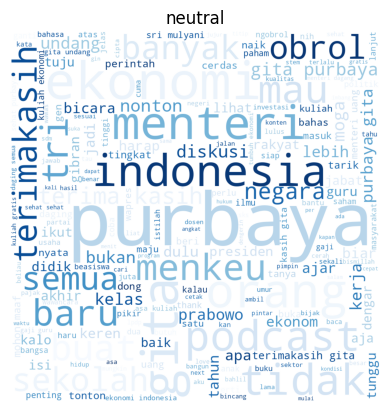

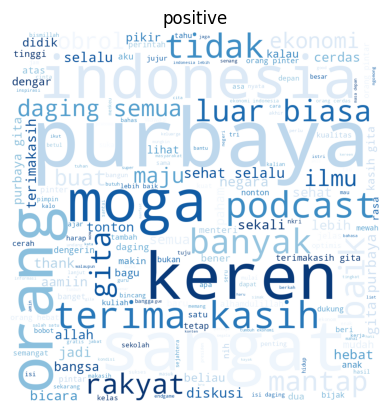

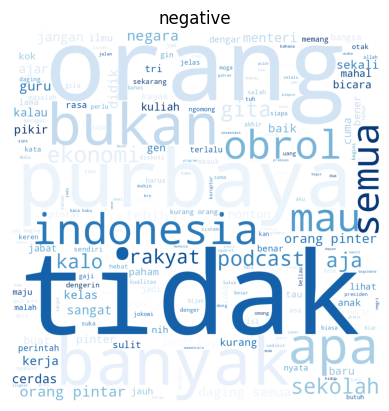

In [33]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

emosi_list = df["sentimen"].unique()

for emosi in emosi_list:
    text = " ".join(df[df["sentimen"] == emosi]["Comment"].astype(str))
    wc = WordCloud(colormap='Blues', width=1000, height=1000, mode="RGBA", background_color='white'  ).generate(text)
    
    plt.figure()
    plt.imshow(wc)
    plt.title(emosi)
    plt.axis("off")
    plt.show()

# Splitting Data

In [34]:
df = df[df['Comment'].astype(str).str.strip().ne('')]
df = df.dropna(subset=["Comment"])

In [36]:
X = df['Comment']
y = df['sentimen']

In [37]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [38]:
print('Banyak data x_train :',len(x_train))
print('Banyak data x_test  :',len(x_test))
print('Banyak data y_train :',len(y_train))
print('Banyak data y_test  :',len(y_test))

Banyak data x_train : 2817
Banyak data x_test  : 705
Banyak data y_train : 2817
Banyak data y_test  : 705


# Training

### Support Vector Machine (SVM) -> Support Vector Classifier Linear

In [39]:
print(df['sentimen'].value_counts())

sentimen
neutral     1296
negative    1271
positive     955
Name: count, dtype: int64


In [40]:
vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(df['Comment']) 
y = df['sentimen']

In [41]:
vectorizer = TfidfVectorizer()
x_train = vectorizer.fit_transform(x_train)
x_test = vectorizer.transform(x_test)

In [42]:
model = LinearSVC(class_weight='balanced')
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [43]:
hasil = model.predict(x_test)

## Classification report

In [44]:
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.65      0.59      0.62       249
     neutral       0.64      0.72      0.68       257
    positive       0.72      0.70      0.71       199

    accuracy                           0.67       705
   macro avg       0.67      0.67      0.67       705
weighted avg       0.67      0.67      0.66       705



## Confusion Matrix

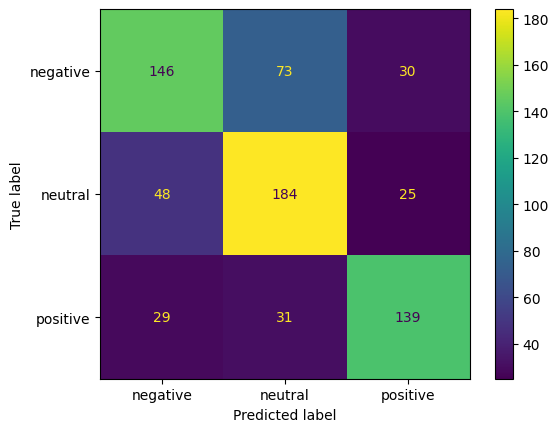

In [45]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# Testing

In [46]:
def classify_text(text):
    text = text.lower()
    text_tfidf = vectorizer.transform([text])
    return model.predict(text_tfidf)[0]

In [47]:
while True:
    input_text = input("\nMasukkan teks (ketik 'exit' untuk keluar): ")
    
    if input_text.lower() == 'exit':
        break
    
    hasil = classify_text(input_text)
    print("Hasil Sentimen:", hasil)


Masukkan teks (ketik 'exit' untuk keluar):  purbaya menjadi menteri


Hasil Sentimen: neutral



Masukkan teks (ketik 'exit' untuk keluar):  purbaya


Hasil Sentimen: neutral



Masukkan teks (ketik 'exit' untuk keluar):  prabowo


Hasil Sentimen: neutral



Masukkan teks (ketik 'exit' untuk keluar):  jaya jaya jaya


Hasil Sentimen: neutral



Masukkan teks (ketik 'exit' untuk keluar):  bagus


Hasil Sentimen: positive



Masukkan teks (ketik 'exit' untuk keluar):  mantap


Hasil Sentimen: positive



Masukkan teks (ketik 'exit' untuk keluar):  exit
